# Automated Road Damage Classification Using Deep Learning and Cloud Deployment

## 03 - Baseline CNN Model

### Objective
To build a basic Convolutional Neural Network (CNN) for
classifying road damage images into Pothole, Crack and Manhole.

In [1]:
# Import TensorFlow for building and training the deep learning model
import tensorflow as tf

# Import layers used to build our CNN model
from tensorflow.keras import layers

# Import Sequential to build the model layer by layer
from tensorflow.keras.models import Sequential

# Import matplotlib to visualize training results
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# Set the project dataset path
# This folder contains train, validation and test images

dataset_path = r"C:\Users\Gopal\Automated_Road_Damage_Classification\dataset"

# Set the image size required by our CNN model
image_size = (224, 224)

# Set the batch size
# The model processes 32 images at a time
batch_size = 32

# Define the three damage classes
# The order of these classes will be used by the model
class_names = ["pothole", "crack", "manhole"]

# Load the training dataset
# Training images are used to teach the model
train_dataset = tf.keras.utils.image_dataset_from_directory(
    f"{dataset_path}\\train",
    image_size=image_size,
    batch_size=batch_size,
    class_names=class_names,
    shuffle=True,
    seed=42
)

# Load the validation dataset
# Validation images are used to check model performance during training
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    f"{dataset_path}\\validation",
    image_size=image_size,
    batch_size=batch_size,
    class_names=class_names,
    shuffle=False
)

# Load the test dataset
# Test images are used only for final model evaluation
test_dataset = tf.keras.utils.image_dataset_from_directory(
    f"{dataset_path}\\test",
    image_size=image_size,
    batch_size=batch_size,
    class_names=class_names,
    shuffle=False
)

print("All datasets loaded successfully!")

Found 702 files belonging to 3 classes.
Found 173 files belonging to 3 classes.
Found 151 files belonging to 3 classes.
All datasets loaded successfully!


In [3]:
# AUTOTUNE allows TensorFlow to automatically select
# the best setting for loading data efficiently
AUTOTUNE = tf.data.AUTOTUNE

# Prefetch the next batch while the current batch is being processed
# This can make model training faster
train_dataset = train_dataset.prefetch(
    buffer_size=AUTOTUNE
)

validation_dataset = validation_dataset.prefetch(
    buffer_size=AUTOTUNE
)

test_dataset = test_dataset.prefetch(
    buffer_size=AUTOTUNE
)

print("Dataset performance optimization completed!")

Dataset performance optimization completed!


In [7]:
# Create a Sequential CNN model
# Sequential allows us to add layers one after another

cnn_model = Sequential([

    # Define the input image size
    # Our model receives RGB images with a size of 224 x 224 pixels
    layers.Input(shape=(224, 224, 3)),

    # Normalize pixel values from 0-255 to 0-1
    # This helps the model learn more effectively
    layers.Rescaling(1.0 / 255),

    # First convolution layer
    # It learns simple features such as edges and textures
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    # Reduce the feature map size
    # This keeps important features and reduces computation
    layers.MaxPooling2D(
        (2, 2)
    ),

    # Second convolution layer
    # It learns more detailed road surface patterns
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    # Reduce the feature map size again
    layers.MaxPooling2D(
        (2, 2)
    ),

    # Third convolution layer
    # It learns more complex damage features
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    # Reduce the feature map size again
    layers.MaxPooling2D(
        (2, 2)
    ),

    # Convert the extracted features into a one-dimensional vector
    layers.Flatten(),

    # Fully connected layer
    # It learns high-level patterns from the extracted features
    layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout helps reduce overfitting
    # 30% of neurons are randomly ignored during training
    layers.Dropout(0.3),

    # Final classification layer
    # Three neurons represent Pothole, Crack and Manhole
    layers.Dense(
        3,
        activation="softmax"
    )
])

# Display the model architecture
# This helps us verify the structure of our CNN
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile the CNN model
# Compilation defines how the model learns from the training data

cnn_model.compile(

    # Adam optimizer adjusts the model weights during training
    optimizer="adam",

    # Sparse categorical crossentropy is suitable for
    # multi-class classification with integer labels
    loss="sparse_categorical_crossentropy",

    # Accuracy shows the percentage of correct predictions
    metrics=["accuracy"]
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


In [11]:
# Define class weights to handle class imbalance
# Manhole has fewer training images, so it receives a higher weight

class_weights = {
    0: 1.00,   # Pothole
    1: 0.58,   # Crack
    2: 3.49    # Manhole
}

print("Class weights:")
print(class_weights)

Class weights:
{0: 1.0, 1: 0.58, 2: 3.49}


Class weights help the model pay more attention to the minority class instead of mainly learning the majority class.

In [12]:
# Import the required callback classes
# Callbacks help us control and save the training process
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Stop training when validation loss stops improving
# This helps prevent overfitting
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Save the model whenever validation performance improves
# This ensures that we keep the best version of the model
model_checkpoint = ModelCheckpoint(
    "baseline_cnn_best.keras",
    monitor="val_loss",
    save_best_only=True
)

print("Training callbacks created successfully!")

Training callbacks created successfully!


EarlyStopping prevents unnecessary training and helps reduce overfitting. ModelCheckpoint saves the best-performing model so we can use it later for evaluation and deployment.

In [13]:
# Train the baseline CNN model
# The model learns road damage patterns from the training images

history = cnn_model.fit(
    train_dataset,

    # Use validation data to check model performance after each epoch
    validation_data=validation_dataset,

    # Train for a maximum of 20 epochs
    # EarlyStopping may stop training earlier if validation performance stops improving
    epochs=20,

    # Apply class weights to handle the imbalance in our dataset
    class_weight=class_weights,

    # Use EarlyStopping and ModelCheckpoint during training
    callbacks=[
        early_stopping,
        model_checkpoint
    ]
)

Epoch 1/20


C:\Users\Gopal\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 915ms/step - accuracy: 0.4487 - loss: 1.2630 - val_accuracy: 0.0925 - val_loss: 1.1014
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 803ms/step - accuracy: 0.2550 - loss: 1.0973 - val_accuracy: 0.0925 - val_loss: 1.1107
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 911ms/step - accuracy: 0.3333 - loss: 1.0971 - val_accuracy: 0.5434 - val_loss: 1.0051
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 881ms/step - accuracy: 0.3832 - loss: 1.0909 - val_accuracy: 0.4566 - val_loss: 1.0001
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 31s 470ms/step - accuracy: 0.3291 - loss: 1.0937 - val_accuracy: 0.3468 - val_loss: 1.0645
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 567ms/step - accuracy: 0.3604 - loss: 1.0782 - val_accuracy: 0.2139 - val_loss: 1.0794
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 532ms/step - accuracy: 0.4003 - loss: 1.0522 - val_accuracy: 0.1965 - val_loss: 1.1635
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 533ms/step - accuracy: 0.2123 - loss: 1.0172 - val_accuracy: 0.179

One epoch means the model has gone through the complete training dataset once.

In [14]:
EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [15]:
history = cnn_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    class_weight=class_weights,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 458ms/step - accuracy: 0.3162 - loss: 1.0605 - val_accuracy: 0.1792 - val_loss: 1.1209
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 754ms/step - accuracy: 0.4003 - loss: 1.0389 - val_accuracy: 0.6012 - val_loss: 1.0607
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 17s 768ms/step - accuracy: 0.5513 - loss: 1.0512 - val_accuracy: 0.4971 - val_loss: 1.0323
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 718ms/step - accuracy: 0.5513 - loss: 0.9849 - val_accuracy: 0.5376 - val_loss: 1.1395
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 15s 684ms/step - accuracy: 0.6040 - loss: 0.9997 - val_accuracy: 0.6358 - val_loss: 1.0198
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 697ms/step - accuracy: 0.5199 - loss: 0.9895 - val_accuracy: 0.6069 - val_loss: 1.2015
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 16s 737ms/step - accuracy: 0.5855 - loss: 0.9593 - val_accuracy: 0.4393 - val_loss: 1.0444
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 787ms/step - accuracy: 0.6040 - loss: 0.9171 - val_accu

In [17]:
# Evaluate the trained CNN model on the unseen test dataset
# Why? We use test data to measure how well the model performs on new images.

test_loss, test_accuracy = cnn_model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.5894 - loss: 0.9090
Test Loss: 0.9090336561203003
Test Accuracy: 0.5894039869308472


“The baseline CNN achieved 58.94% accuracy on the unseen test dataset. This baseline was then used for comparison with transfer-learning models.”

In [18]:
# Import libraries required for evaluation
# Why? These libraries help us calculate detailed classification metrics.
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get the true labels and predicted probabilities from the test dataset
# Why? We need the actual labels and model predictions to calculate metrics.
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = cnn_model.predict(images, verbose=0)

    # Convert prediction probabilities into the predicted class number
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

# Convert lists into NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

Classification Report:
              precision    recall  f1-score   support

     pothole     0.6087    0.4516    0.5185        62
       crack     0.6667    0.7500    0.7059        72
     manhole     0.2917    0.4118    0.3415        17

    accuracy                         0.5894       151
   macro avg     0.5223    0.5378    0.5220       151
weighted avg     0.6006    0.5894    0.5879       151



Crack:
The CNN performs relatively better here. Recall is 75%, meaning it detected 75 out of 100 actual crack samples approximately.

Pothole:
Performance is moderate. Recall is 45.16%, so the model is missing a significant number of actual pothole samples.

Manhole:
This is the weakest class. F1-score is only 34.15%. One reason is that we have only 17 manhole images in the test set, compared with 62 pothole and 72 crack samples.

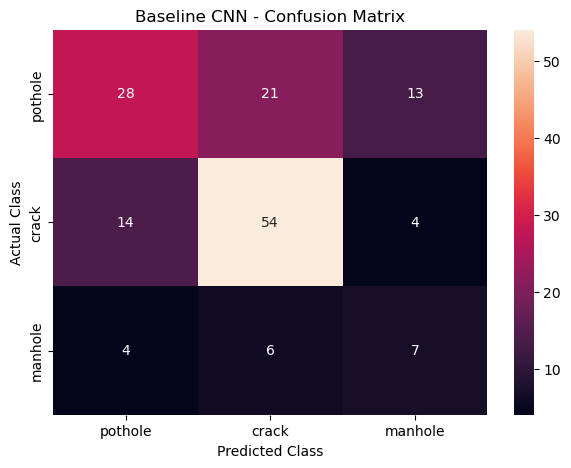

In [19]:
# Create the confusion matrix
# Why? It shows which damage classes the model is confusing with each other.

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Baseline CNN - Confusion Matrix")
plt.show()

“The confusion matrix shows that the baseline CNN performs better in recognizing cracks, while potholes and manholes are more frequently misclassified. In particular, confusion between pothole and crack is significant. Therefore, a more powerful feature extraction approach using transfer learning is required.”

In [1]:
print(history)

NameError: name 'history' is not defined